In [1]:
]activate ../../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
includet("./base.jl")

┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Symbolics → SymbolicsForwardDiffExt
│  └─ Symbolics → SymbolicsPreallocationToolsExt
│ Precompilation will also be skipped for the following, which depend on the above cycle:
│   SSMC
│   MLSolver
└ @ Pkg.API.Precompilation ~/.julia/juliaup/julia-1.10.10+0.x64.linux.gnu/share/julia/stdlib/v1.10/Pkg/src/precompilation.jl:583
Precompiling packages...
  14304.8 ms  ✓ SSMCMain
  1 dependency successfully precompiled in 18 seconds. 544 already precompiled. 4 skipped due to circular dependency.


In [3]:
using CairoMakie
using GLMakie
CairoMakie.activate!()

# Looking at data

In [80]:
f = jldopen("./data1.jld2")
f2 = jldopen("./sys1.jld2")
df = f["df"];

In [81]:
N, M = get_Ns(df.params[1])
sN = size(df.sol_us[1][1], 2)

1000

In [82]:
df.means = [map(df.sol_us[i]) do u reshape(mean(u; dims=2), N+M) end for i in 1:nrow(df)];

In [87]:
df.totbioms = [map(mm) do mu sum(mu[1:N]) end for mm in df.means];

In [101]:
df.fTs = last.(df.sol_ts)

8-element Vector{Float64}:
  67925.64695702985
  63267.90716062832
 347903.44791166
  34306.59256706952
 122077.57475768028
      5.74504058749572e7
      1.0202301734422356e7
      1.0e8

In [98]:
df.maxresids

8-element Vector{Float64}:
 0.17826624755589424
 0.2466589612232582
 0.02109406879848108
 0.021270102270502217
 0.010864592801849482
 1.7257894568967203e-7
 2.9067393031434463e-7
 2.8101965199311962e-11

## Total biomass in time

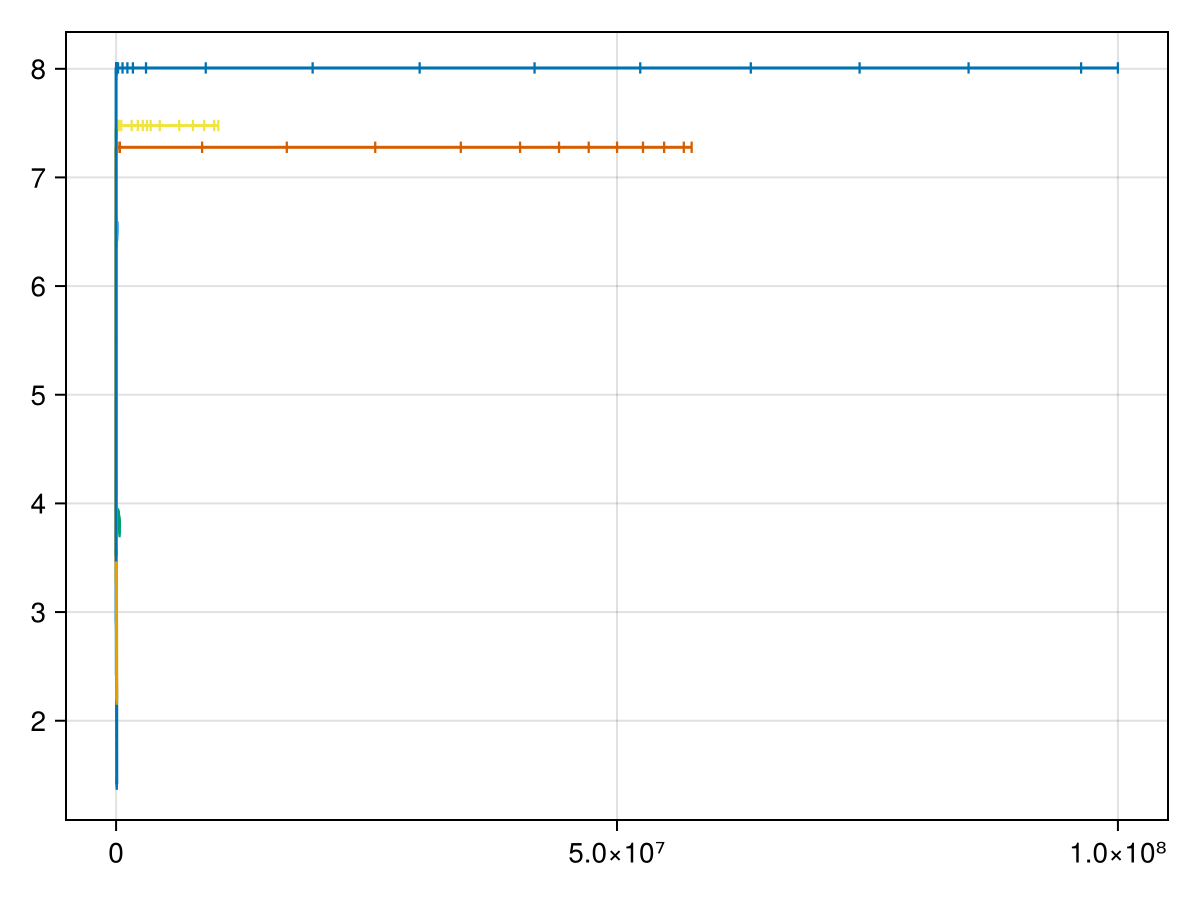

In [97]:
fig = Figure()
ax = Axis(fig[1,1];
    # xscale=log10,
)

for r in eachrow(df)
    scatterlines!(ax, r.sol_ts, r.totbioms;
        marker=:vline
    )
end

# display(GLMakie.Screen(), fig)

fig

## ??